# **Project Name**    - 
United Nation Global Terrorism Analysis
Exploratory Data Analysis




# **Project Summary -**
In this project, I analyzed a global terrorism dataset covering the years 1970 to 2017 to understand how terrorist activities have evolved over time. Since terrorism has a major impact on security, economies, and public safety, the goal was to extract meaningful insights that could help in better decision-making.

The dataset contains over 180,000 records with details like year, country, region, attack type, terrorist group, and casualties. Before starting the analysis, I cleaned and prepared the data by handling missing values, selecting important columns, and standardizing inconsistent entries. For example, missing casualty values were replaced with zeros, and unknown group names were made consistent.
I then performed exploratory data analysis (EDA) to identify trends and patterns. One key finding was that the number of terrorist attacks has increased over time, especially after the early 2000s. I also found that attacks are not evenly spread across the world—regions like the Middle East and North Africa are much more affected.

Looking deeper into attack types, bombings and armed assaults turned out to be the most common methods used. I also used a WordCloud to highlight the most active terrorist groups, which showed that a small number of groups are responsible for a large share of attacks.
To better understand the impact, I created a new feature called “total casualties” by combining deaths and injuries. This helped identify high-impact periods and showed that attacks by known groups usually result in higher casualties than those by unknown groups.

Overall, this project helped uncover important patterns in global terrorism. The insights can be useful for governments and organizations to identify high-risk areas, improve security strategies, and allocate resources more effectively.

# **Problem Statement**
The objective of this project is to analyze global terrorism data to uncover patterns, trends, and meaningful insights. It focuses on identifying the most affected regions and countries, understanding how terrorist activities have changed over time, and validating key assumptions—such as whether certain regions experience higher attack frequencies and whether unclaimed attacks result in fewer casualties.

#### **Define Your Business Objective?**
The goal of this analysis is to support governments, policymakers, and security agencies in better understanding global terrorism patterns. By identifying high-risk regions, tracking trends, and analyzing attack behavior, the project aims to enable data-driven decision-making, improve security planning, and strengthen counter-terrorism strategies.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn as sk
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# 1. Understand data

In [3]:
df =pd.read_csv('Global Terrorism Data.csv',encoding='latin-1')

In [4]:
df.head(5)

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


In [5]:
df.shape

(181691, 135)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(55), int64(22), object(58)
memory usage: 187.1+ MB


In [7]:
df.duplicated().sum()

0

In [8]:
df.isnull().sum()

eventid            0
iyear              0
imonth             0
iday               0
approxdate    172452
               ...  
INT_LOG            0
INT_IDEO           0
INT_MISC           0
INT_ANY            0
related       156653
Length: 135, dtype: int64

In [9]:
df.isnull()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,False,False,False,False,True,False,True,False,False,False,...,True,True,True,True,False,False,False,False,False,True
1,False,False,False,False,True,False,True,False,False,False,...,True,True,True,True,False,False,False,False,False,True
2,False,False,False,False,True,False,True,False,False,False,...,True,True,True,True,False,False,False,False,False,True
3,False,False,False,False,True,False,True,False,False,False,...,True,True,True,True,False,False,False,False,False,True
4,False,False,False,False,True,False,True,False,False,False,...,True,True,True,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181686,False,False,False,False,True,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
181687,False,False,False,False,True,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
181688,False,False,False,False,True,False,True,False,False,False,...,True,False,True,True,False,False,False,False,False,True
181689,False,False,False,False,True,False,True,False,False,False,...,True,False,True,True,False,False,False,False,False,True


### What did you know about your dataset?

It is a comprehensive global terrorism dataset (1970–2017) containing detailed information on attacks, including location, type, casualties, and responsible groups.

## ***2. Understanding Your Variables***

In [10]:
df.columns

Index(['eventid', 'iyear', 'imonth', 'iday', 'approxdate', 'extended',
       'resolution', 'country', 'country_txt', 'region',
       ...
       'addnotes', 'scite1', 'scite2', 'scite3', 'dbsource', 'INT_LOG',
       'INT_IDEO', 'INT_MISC', 'INT_ANY', 'related'],
      dtype='object', length=135)

In [11]:
df.describe()

,eventid,iyear,imonth,iday,extended,country,region,latitude,longitude,specificity,...,ransomamt,ransomamtus,ransompaid,ransompaidus,hostkidoutcome,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY
count,1.816910e+05,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,177135.000000,1.771340e+05,181685.000000,...,1.350000e+03,5.630000e+02,7.740000e+02,552.000000,10991.000000,10400.000000,181691.000000,181691.000000,181691.000000,181691.000000
mean,2.002705e+11,2002.638997,6.467277,15.505644,0.045346,131.968501,7.160938,23.498343,-4.586957e+02,1.451452,...,3.172530e+06,5.784865e+05,7.179437e+05,240.378623,4.629242,-29.018269,-4.543731,-4.464398,0.090010,-3.945952
std,1.325957e+09,13.259430,3.388303,8.814045,0.208063,112.414535,2.933408,18.569242,2.047790e+05,0.995430,...,3.021157e+07,7.077924e+06,1.014392e+07,2940.967293,2.035360,65.720119,4.543547,4.637152,0.568457,4.691325
min,1.970000e+11,1970.000000,0.000000,0.000000,0.000000,4.000000,1.000000,-53.154613,-8.618590e+07,1.000000,...,-9.900000e+01,-9.900000e+01,-9.900000e+01,-99.000000,1.000000,-99.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,1.991021e+11,1991.000000,4.000000,8.000000,0.000000,78.000000,5.000000,11.510046,4.545640e+00,1.000000,...,0.000000e+00,0.000000e+00,-9.900000e+01,0.000000,2.000000,-99.000000,-9.000000,-9.000000,0.000000,-9.000000
50%,2.009022e+11,2009.000000,6.000000,15.000000,0.000000,98.000000,6.000000,31.467463,4.324651e+01,1.000000,...,1.500000e+04,0.000000e+00,0.000000e+00,0.000000,4.000000,0.000000,-9.000000,-9.000000,0.000000,0.000000
75%,2.014081e+11,2014.000000,9.000000,23.000000,0.000000,160.000000,10.000000,34.685087,6.871033e+01,1.000000,...,4.000000e+05,0.000000e+00,1.273412e+03,0.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,2.017123e+11,2017.000000,12.000000,31.000000,1.000000,1004.000000,12.000000,74.633553,1.793667e+02,5.000000,...,1.000000e+09,1.320000e+08,2.750000e+08,48000.000000,7.000000,2769.000000,1.000000,1.000000,1.000000,1.000000


# Variable discription

The dataset consists of multiple variables that describe different aspects of terrorist incidents. The key variables used in this analysis are:

iyear: Represents the year in which the terrorist attack occurred. It helps in analyzing trends over time.
country_txt: Indicates the name of the country where the attack took place. This is useful for country-wise analysis.
region_txt: Describes the region of the world (e.g., Middle East & North Africa, South Asia). It helps in regional comparisons.
attacktype1_txt: Specifies the type of attack carried out, such as bombing, assassination, or armed assault.
gname: Refers to the name of the terrorist group responsible for the attack. If unknown, it is labeled as "Unknown Group".
nkill: Represents the number of people killed in the attack. It is used to measure the severity of incidents.
nwound: Indicates the number of people injured during the attack.
total_casualties: A derived variable calculated as the sum of killed and wounded (nkill + nwound), representing the total impact of the attack.

In [12]:
for col in df.columns:
  print(f'{col}:{df[col].unique()}')

eventid:[197000000001 197000000002 197001000001 ... 201712310030 201712310031
 201712310032]
iyear:[1970 1971 1972 1973 1974 1975 1976 1977 1978 1979 1980 1981 1986 1982
 1983 1984 1985 1987 1988 1989 1990 1991 1992 1994 1995 1996 1997 1998
 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012
 2013 2014 2015 2016 2017]
imonth:[ 7  0  1  2  3  4  5  6  8  9 10 11 12]
iday:[ 2  0  1  3  6  8  9 10 11 12 13 14 15 19 20 21 22 25 26 27 28 30 31  4
  7 16 17 18 23 24  5 29]
approxdate:[nan 'January 19-20, 1970' 'February 6-9, 1970' ... '2017-12-29 00:00:00'
 'December 25, 2017-January 5, 2018' '2017-12-31 00:00:00']
extended:[0 1]
resolution:[nan '3/8/1970' '3/15/1970' ... '3/23/2013' '12/9/2011' '12/27/2011']
country:[  58  130  160   78  101  217  218   98  499   65   83  222  362  199
  102  185   30   60   11  110   96  209  158   94  603   45   26  145
  142   21   38   14  153  230  198   49  406   36   97  161  201  156
  106  155   15  236   92   69  428   31  604  

# 3. Data Cleaning

In [13]:
df = df[['iyear','country_txt','region_txt','attacktype1_txt','gname','nkill','nwound']]

df['nkill'] = df['nkill'].fillna(0)
df['nwound'] = df['nwound'].fillna(0)

df['gname'] = df['gname'].replace("Unknown", "Unknown Group")

In [14]:
df['gname']

0                                             MANO-D
1                 23rd of September Communist League
2                                      Unknown Group
3                                      Unknown Group
4                                      Unknown Group
                             ...                    
181686                                    Al-Shabaab
181687                             Muslim extremists
181688    Bangsamoro Islamic Freedom Movement (BIFM)
181689                                 Unknown Group
181690                                 Unknown Group
Name: gname, Length: 181691, dtype: object

### What all manipulations have you done and insights you found?

The dataset was cleaned by selecting relevant columns, handling missing values, and creating a new feature for total casualties. Data was then aggregated by year, country, and region to support visualization.

The insights from the visualizations show that terrorist attacks have increased over time, are highly concentrated in regions like the Middle East & North Africa, and are dominated by a few countries and groups. Additionally, common attack types such as bombings and armed assaults are frequently used, and unknown groups tend to have slightly lower casualties.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***



# Chart 1

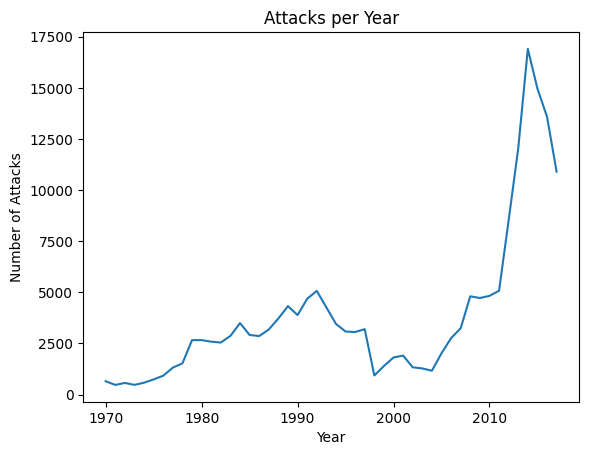

In [15]:
plt.figure()
df['iyear'].value_counts().sort_index().plot()
plt.title("Attacks per Year")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")
plt.show()

##### 1. Why did you pick the specific chart?abs
A line chart is used to show trends over time clearly.


##### 2. What is/are the insight(s) found from the chart?
Terrorist attacks have increased significantly over the years, especially after 2000.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

#### Chart - 2

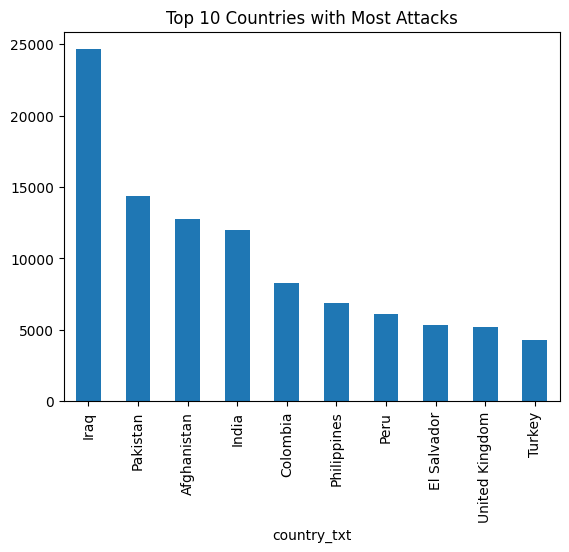

In [16]:
plt.figure()
df['country_txt'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries with Most Attacks")
plt.show()

##### 1. Why did you pick the specific chart?


##### 2. What is/are the insight(s) found from the chart
A bar chart is ideal for comparing values across different categories.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

#### Chart - 3

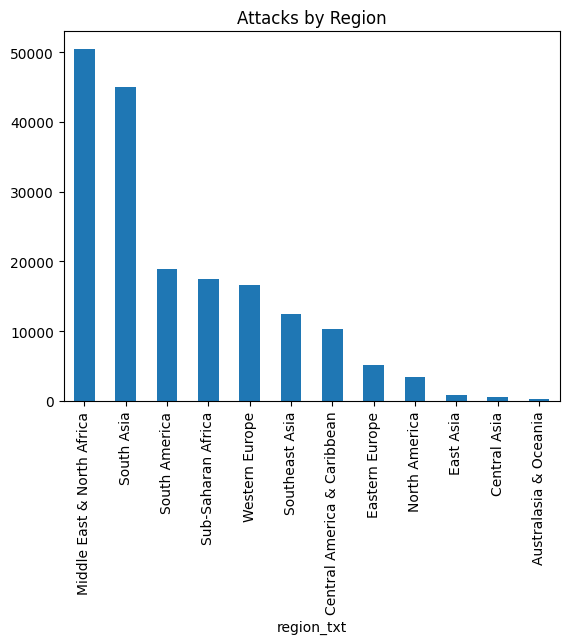

In [17]:
plt.figure()
df['region_txt'].value_counts().plot(kind='bar')
plt.title("Attacks by Region")
plt.show()

##### 1. Why did you pick the specific chart?
Bar charts make it easy to compare attack counts across regions.

##### 2. What is/are the insight(s) found from the chart?
Middle East & North Africa region has the highest number of attacks.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
, it helps in prioritizing resources in high-risk regions.

#### Chart - 4

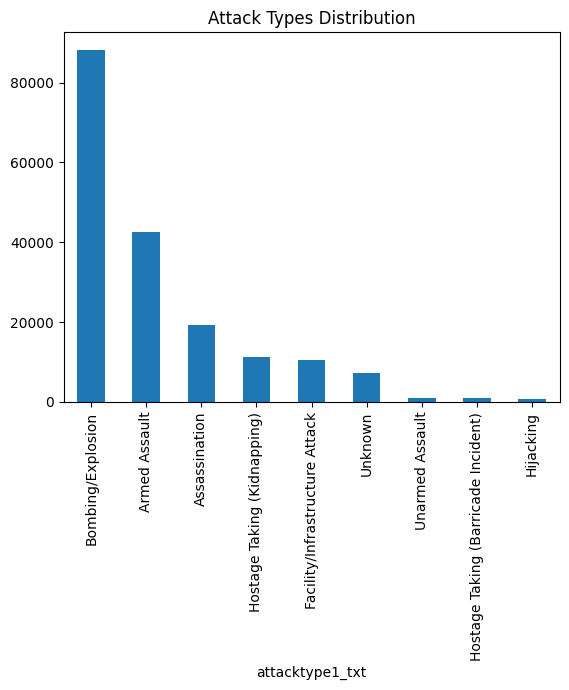

In [18]:
plt.figure()
df['attacktype1_txt'].value_counts().plot(kind='bar')
plt.title("Attack Types Distribution")
plt.show()

##### 1. Why did you pick the specific chart?
Bar chart helps in comparing frequency of different attack types.

##### 2. What is/are the insight(s) found from the chart?
Bombings and armed assaults are the most commonly used attack methods.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
Yes, it helps in preparing defense strategies against common attack types.


#### Chart - 5

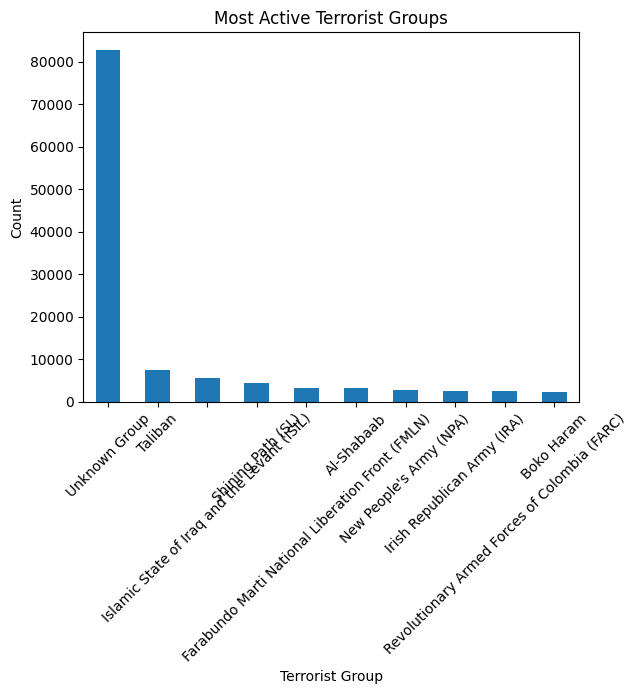

In [20]:
# Count frequency
counts = df['gname'].value_counts().head(10)

# Plot
counts.plot(kind='bar')

plt.xlabel("Terrorist Group")
plt.ylabel("Count")
plt.title("Most Active Terrorist Groups")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?
WordCloud visually highlights the most frequent group names.

##### 2. What is/are the insight(s) found from the chart?
A few terrorist groups appear frequently, indicating their dominance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
    Yes, it helps in identifying key groups for targeted counter-terrorism actions.

#### Chart - 6

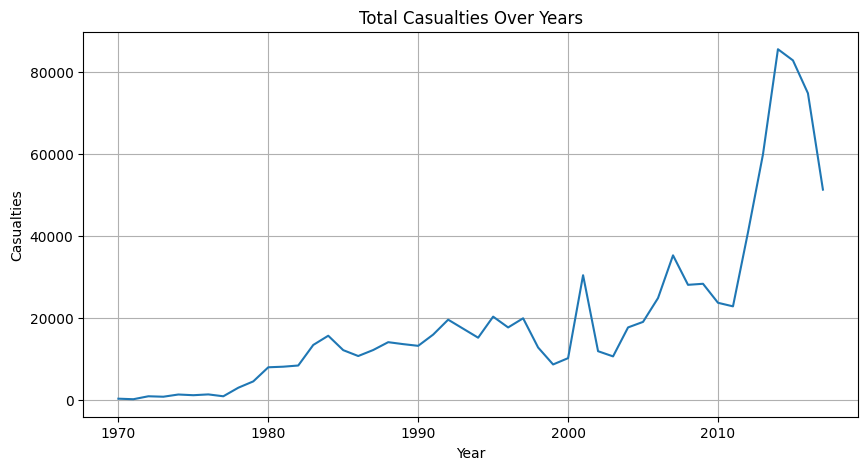

In [23]:
df['total_casualties'] = df['nkill'] + df['nwound']

plt.figure(figsize=(10,5))
df.groupby('iyear')['total_casualties'].sum().plot()
plt.title("Total Casualties Over Years")
plt.xlabel("Year")
plt.ylabel("Casualties")
plt.grid()
plt.show()

##### 1. Why did you pick the specific chart?
A line chart is useful to show trends in casualties over time.



##### 2. What is/are the insight(s) found from the chart?
Casualties fluctuate but show peaks during certain years, indicating high-impact events.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
    Yes, it helps in understanding high-risk periods, but increasing casualties indicate negative societal and economic impact.

#### Chart - 7

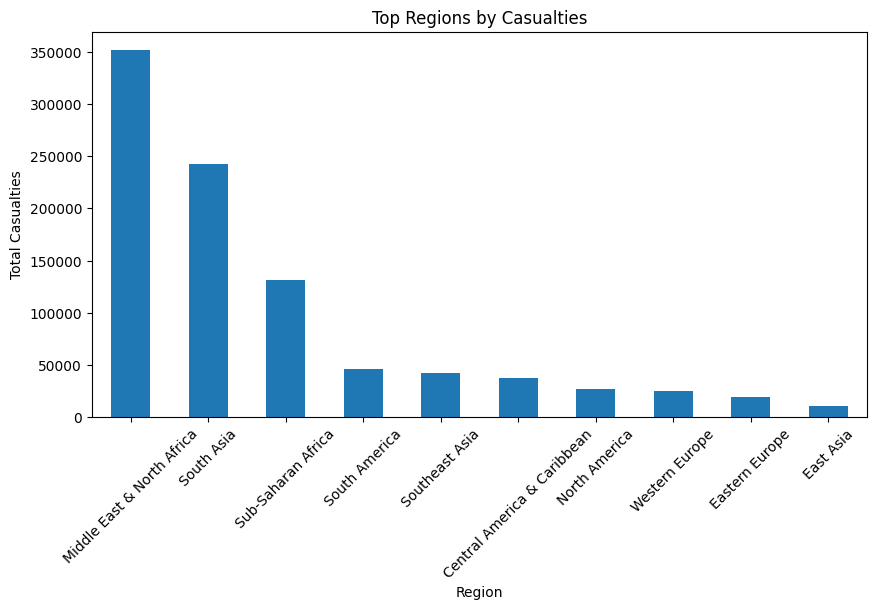

In [26]:
plt.figure(figsize=(10,5))
df.groupby('region_txt')['total_casualties'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Regions by Casualties")
plt.xlabel("Region")
plt.ylabel("Total Casualties")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?
Bar chart allows comparison of casualties across regions.

##### 2. What is/are the insight(s) found from the chart?
Certain regions have significantly higher casualties than others.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
    Yes, it helps allocate resources effectively, but high casualties indicate severe negative impact on those regions.
    

#### Chart - 8

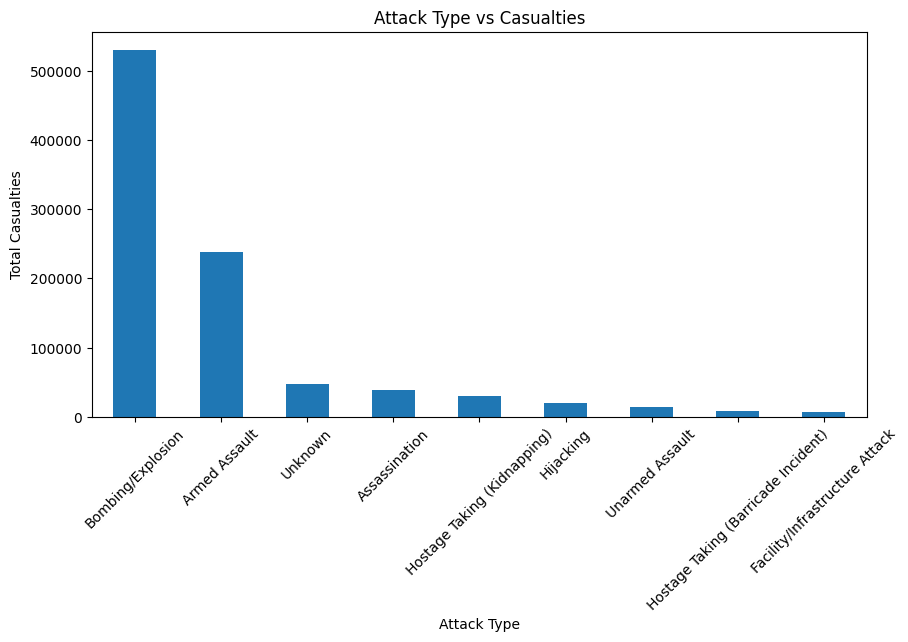

In [28]:
plt.figure(figsize=(10,5))
df.groupby('attacktype1_txt')['total_casualties'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title("Attack Type vs Casualties")
plt.xlabel("Attack Type")
plt.ylabel("Total Casualties")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?
This chart helps compare the impact of different attack types.

##### 2. What is/are the insight(s) found from the chart?
Some attack types (like bombings) result in higher casualties than others.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
    Yes, it helps prepare for high-impact attack types, though frequent severe attacks harm economic growth.

#### Chart - 9

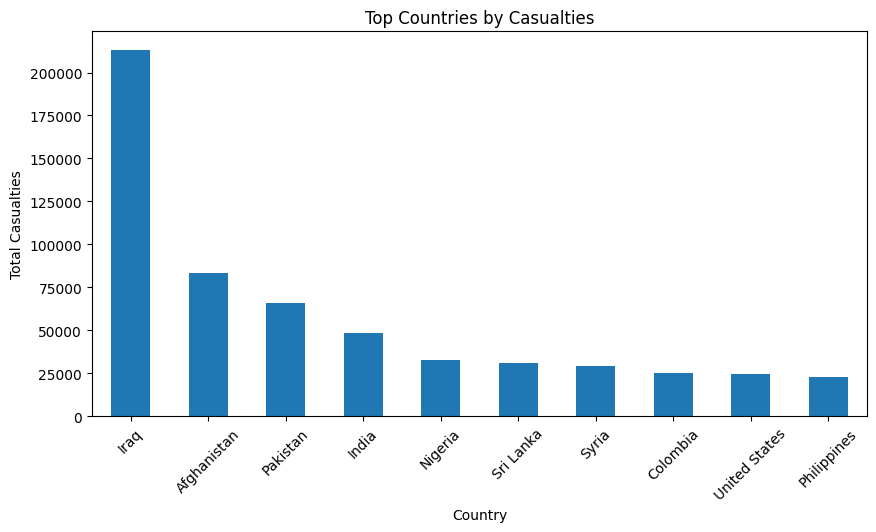

In [29]:
plt.figure(figsize=(10,5))
df.groupby('country_txt')['total_casualties'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Countries by Casualties")
plt.xlabel("Country")
plt.ylabel("Total Casualties")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?
Bar chart is suitable for comparing casualties across countries.

##### 2. What is/are the insight(s) found from the chart?
Certain countries experience significantly higher casualties.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
    Yes, it helps identify vulnerable countries, but high casualties negatively affect development.

#### Chart - 10

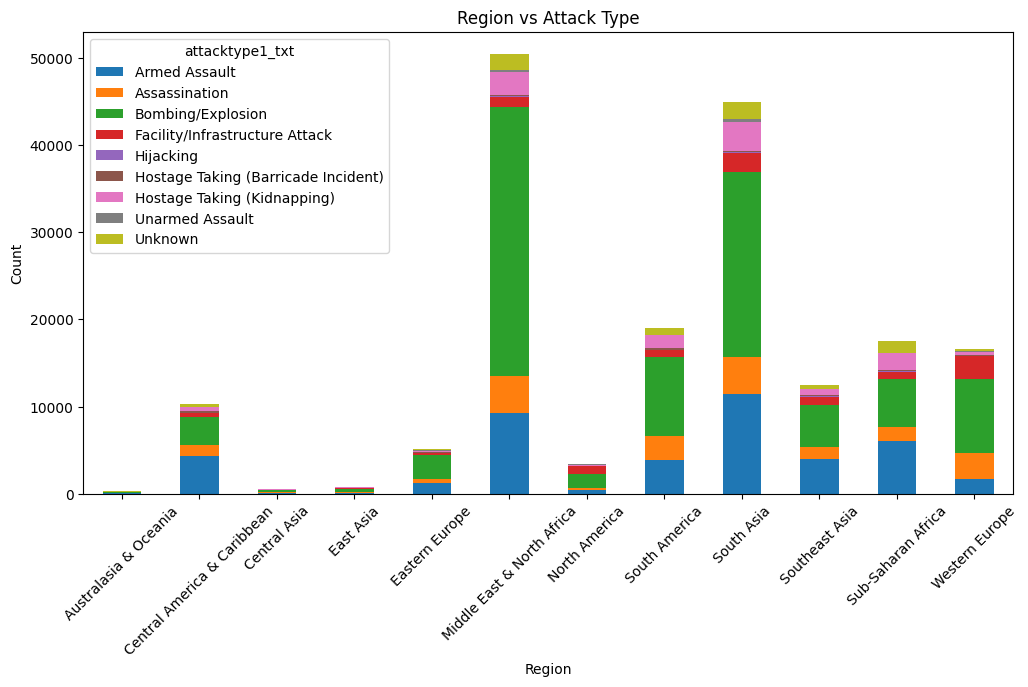

In [30]:
pivot = pd.crosstab(df['region_txt'], df['attacktype1_txt'])

pivot.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Region vs Attack Type")
plt.xlabel("Region")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?
It helps understand how attack types vary across regions.

##### 2. What is/are the insight(s) found from the chart?
Different regions prefer different attack methods.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
    Yes, it helps in region-specific defense planning, though variation indicates complex challenges.

#### Chart - 11

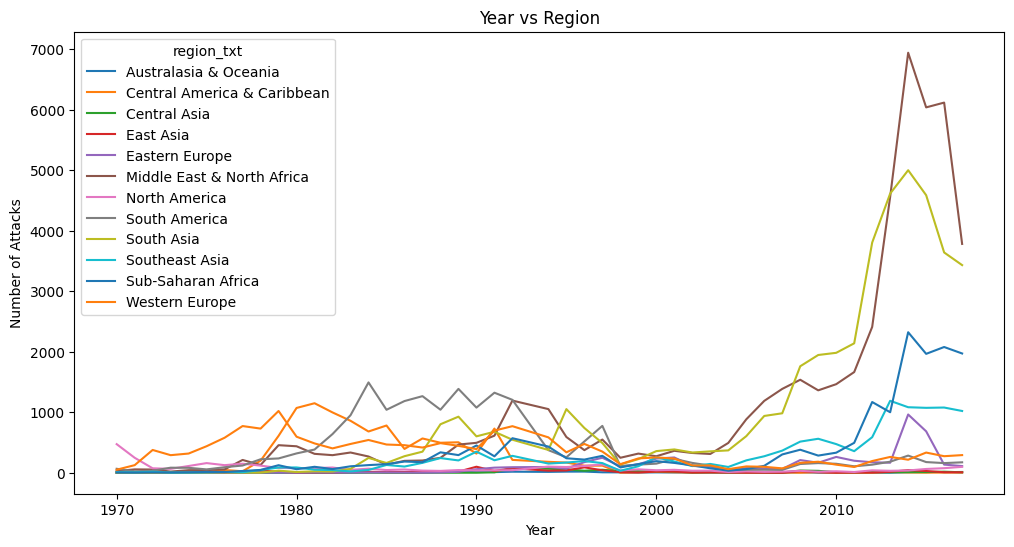

In [32]:
year_region = pd.crosstab(df['iyear'], df['region_txt'])

year_region.plot(figsize=(12,6))
plt.title("Year vs Region")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")
plt.show()

##### 1. Why did you pick the specific chart?
To observe how attacks vary across regions over time.

##### 2. What is/are the insight(s) found from the chart?
Certain regions show increasing trends in attacks over time.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
    Yes, it helps track regional risks, but increasing trends indicate worsening conditions.

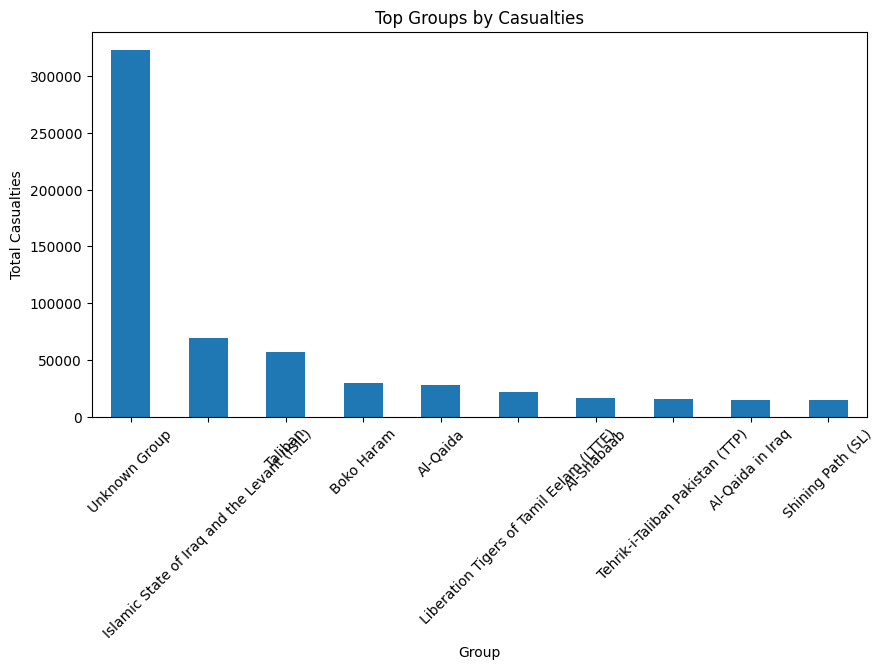

In [34]:
#### Chart - 13
plt.figure(figsize=(10,5))
df.groupby('gname')['total_casualties'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Groups by Casualties")
plt.xlabel("Group")
plt.ylabel("Total Casualties")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?
To compare the impact of different terrorist groups.

##### 2. What is/are the insight(s) found from the chart?
Some groups are responsible for more severe attacks.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
Yes, it helps identify dangerous groups, but high severity indicates serious threats.

#### Chart - 14 - Correlation Heatmap


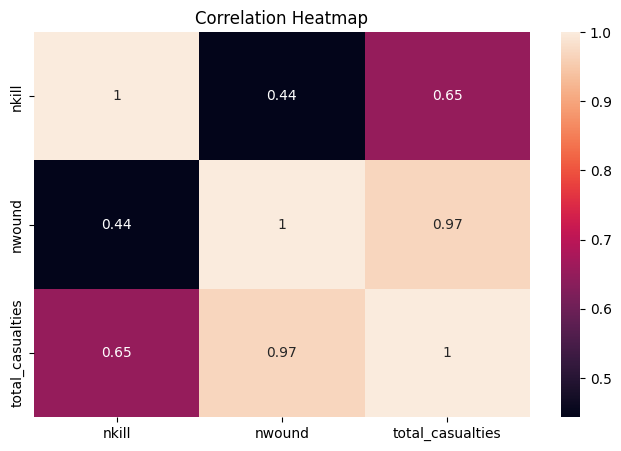

In [35]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['nkill','nwound','total_casualties']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?
A heatmap helps visualize relationships between numerical variables.

##### 2. What is/are the insight(s) found from the chart?
There is a strong positive correlation between number of kills and wounded, indicating that severe attacks result in higher casualties.

#### Chart - 15 - Pair Plot

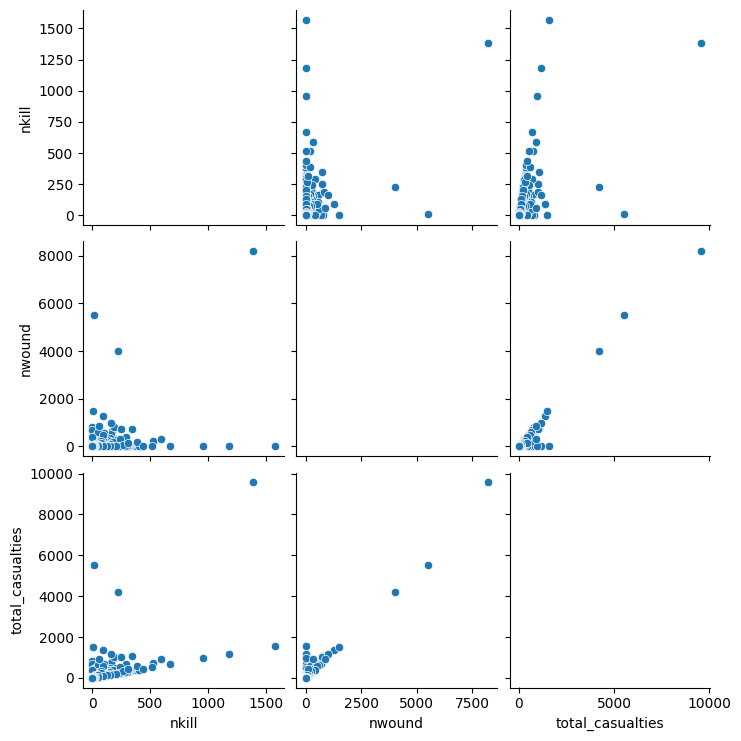

In [36]:
sns.pairplot(df[['nkill','nwound','total_casualties']])
plt.show()

##### 1. Why did you pick the specific chart?
Pair plot helps visualize relationships and distributions between multiple variables.

##### 2. What is/are the insight(s) found from the chart?

Variables like kills and wounded show clear relationships and distribution patterns.Answer Here

## **5. Solution to Business Objective**
To achieve the business objective, the insights from this analysis can be used to identify and prioritize high-risk regions. Governments and security agencies should focus resources on the most affected areas, closely monitor activities of major terrorist groups, and design targeted strategies based on common attack patterns. Implementing interactive dashboards and continuous data monitoring can further support quick, data-driven decision-making and improve overall risk management.

# **Conclusion**.
The project effectively analyzed global terrorism data and revealed key insights such as the increasing trend of attacks, their concentration in specific regions, and the influence of major terrorist groups. These findings can help organizations strengthen counter-terrorism efforts, optimize resource allocation, and improve global security planning.

